Implement the Skip-gram with Negative Sampling (SGNS) algorithm of Word2 Vec in pure Python. Deep learning frameworks are not allowed. You may use NumPy for numerical computations.
# Skip-Gram Negative Sampling
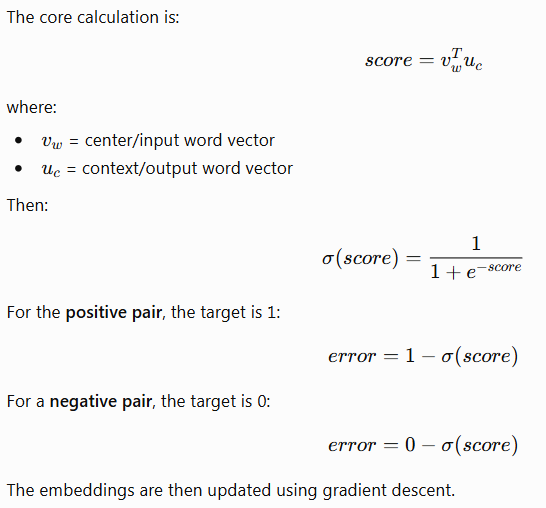

In [1]:
# Import libraries
import numpy as np
import re

# 1. Training Corpus
corpus = [
    "I love natural language processing",
    "I love machine learning",
    "machine learning is interesting",
    "natural language processing is interesting",
    "I like deep learning",
    "deep learning is powerful"
]

# 2. Preprocessing
def preprocess(corpus):
    sentences = []  # Creates an empty list to store the processed sentences

    for sentence in corpus: # Loops through every sentence in the corpus
        # Convert to lowercase
        sentence = sentence.lower() 

        # Keep only words
        # \b matches word boundaries (positions between word and non-word characters)
        # \w+ matches one or more word characters (letters, digits, and underscores)
        # This extracts each individual word as a separate item in a list
        words = re.findall(r'\b\w+\b', sentence)  # Extracts individual words from sentence

        sentences.append(words)  # Adds the list of words to sentences

    return sentences  # Returns the processed sentences


sentences = preprocess(corpus)  # Calls the preprocessing function

print("Processed Corpus:")
for sentence in sentences:   # Loops through each preprocessed sentence
    print(sentence)   # Prints every processed sentence


# 3. Build Vocabulary
word_counts = {}  # Creates an empty dictionary to store: word → frequency

for sentence in sentences:  # Loops through each sentence
    for word in sentence:   # Loops through each word
        word_counts[word] = word_counts.get(word, 0) + 1  # Counts how many times each word occurs

vocab = sorted(word_counts.keys())   # Gets all unique words and sorts them alphabetically

word_to_id = {word: i for i, word in enumerate(vocab)}  # Assigns an integer ID to every word
id_to_word = {i: word for word, i in word_to_id.items()}  # Creates the reverse dictionary ID → word

vocab_size = len(vocab)  # Finds the number of unique words

print("\nVocabulary:")
print(word_to_id)

print("\nVocabulary Size:", vocab_size)

# 4. Convert Corpus to Word IDs
corpus_ids = []  # Creates an empty list

for sentence in sentences:   # Creates an empty list
    corpus_ids.append([word_to_id[word] for word in sentence])  # Converts every word into its numerical ID

print("\nCorpus IDs:")
print(corpus_ids)

# 5. Generate Skip-gram Training Pairs
def generate_training_pairs(corpus_ids, window_size=2):  # window_size=2 means we look at up to 2 words before and 2 words after the center word

    pairs = []   # Creates an empty list for training pairs

    for sentence in corpus_ids:  # Loops through each sentence

        for i, center_word in enumerate(sentence):  # Loops through each word, i is the position, center_word is the current word

            start = max(0, i - window_size)  # Calculates where the context window starts
            end = min(len(sentence), i + window_size + 1)  # Calculates where the context window ends, min() prevents going beyond the sentence

            for j in range(start, end):  # Loops through the words inside the window

                if i != j:    # Center word itself isn't selected as its own context
                    context_word = sentence[j]  # Gets the context word

                    pairs.append((center_word, context_word))  # Stores: (center word, context word) to pairs

    return pairs  # Returns all Skip-gram pairs

window_size = 2   # Sets the cotext window to 2

training_pairs = generate_training_pairs(corpus_ids, window_size # Generates the training pairs

print("\nNumber of training pairs:", len(training_pairs))

print("\nFirst 10 Training Pairs:")

for center, context in training_pairs[:10]:
    print(id_to_word[center], "->", id_to_word[context])


# 6. Negative Sampling Distribution
# Word2Vec uses frequency^0.75 for negative sampling.
# Creates a NumPy array containing word frequencies

frequencies = np.array(                
    [word_counts[word] for word in vocab],
    dtype=np.float64
)

probabilities = frequencies ** 0.75   # Raises each frequency to the power 0.75, Word2Vec uses this special distribution for negative sampling
probabilities = probabilities / probabilities.sum()  # Converts the values into probabilities whose total is 1

print("\nNegative Sampling Probabilities:")

for i, word in id_to_word.items():
    print(word, ":", probabilities[i])


# 7. Sigmoid Function
def sigmoid(x):

    # Prevent numerical overflow
    x = np.clip(x, -15, 15)   # Restricts x between -15 and 15, prevents numerical overflow when calculating exp()

    return 1.0 / (1.0 + np.exp(-x))  # Sigmoid converts the score into a value between 0 and 1


# 8. SGNS Word2Vec Model
class Word2VecSGNS:    # Creates Word2Vec SGNS class

    def __init__(self, vocab_size, embedding_dim=50, learning_rate=0.025, negative_samples=5):  # Constructor
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.learning_rate = learning_rate
        self.negative_samples = negative_samples

        # Input embeddings --> Create input/center-word embedding matrix
        self.W_in = np.random.uniform(-0.5 / embedding_dim, 0.5 / embedding_dim, (vocab_size, embedding_dim))

        # Output embeddings --> Context/output embeddings, Initially all values are zero
        self.W_out = np.zeros((vocab_size, embedding_dim))


    # Train one positive pair + negative samples
    def train_pair(self, center_word, context_word, negative_distribution):

        # Get center word vector --> Gets the embedding of the center word
        center_vector = self.W_in[center_word].copy()

        # Positive sample --> Gets the output vector of the actual context word
        context_vector = self.W_out[context_word].copy()

        score = np.dot(center_vector, context_vector)  # Calculates the dot product, high score means the two words are becoming more related

        prediction = sigmoid(score)    # Converts the score to a probability

        # Error = target - prediction
        error = 1.0 - prediction

        # Gradient for center word
        center_gradient = error * context_vector  # Calculates gradient used to update the center word vector

        # Update output vector
        self.W_out[context_word] += (self.learning_rate * error * center_vector)


        # Negative samples --> Generate Negative Samples
        negative_words = np.random.choice(
            self.vocab_size,
            size=self.negative_samples,
            p=negative_distribution
        )

        for negative_word in negative_words:  # Processes each negative word

            # Avoid selecting the actual positive context
            if negative_word == context_word:   # If the randomly selected word happens to be the actual positive context word, skip it
                continue

            negative_vector = self.W_out[negative_word].copy()  # Gets the output embedding of the negative word

            score = np.dot(center_vector, negative_vector)  # Calculates similarity between the center word and negative word

            prediction = sigmoid(score)   # Converts the score to a probability

            # Target = 0 --> For negative samples, the desired target is 0
            error = 0.0 - prediction

            center_gradient += (error * negative_vector)   # Adds the negative sample's gradient to the center-word gradient

            self.W_out[negative_word] += (self.learning_rate * error * center_vector) # Updates the negative word's output vector


        # Update center word embedding
        self.W_in[center_word] += (self.learning_rate * center_gradient)


    # Train complete model
    def train(self, training_pairs, negative_distribution, epochs=100):

        for epoch in range(epochs):  # Repeats training for each epoch

            # Shuffle training pairs randomly, avoid learning from the same ordering every time
            np.random.shuffle(training_pairs)

            for center_word, context_word in training_pairs:  # Takes one training pair at a time

                self.train_pair(center_word, context_word, negative_distribution) # Train that pair

            if (epoch + 1) % 10 == 0:  # Checks whether 10 epochs have completed, Displays training progress
                print("Epoch", epoch + 1, "completed")


    # Get embedding
    def get_embedding(self, word_id): # Function to retrieve a word's vector

        return self.W_in[word_id]  # Returns the input embedding of that word


    # Find similar words --> Finds the words whose embeddings are most similar to a given word
    def most_similar(self, word_id, top_n=5):

        target = self.W_in[word_id]  # Gets the target word's embedding

        # Normalize vectors --> Normalizes the target vector
        target_norm = (
            target /
            (np.linalg.norm(target) + 1e-10)
        )

        # Normalizes every word vector
        embeddings_norm = (
            self.W_in /
            (
                np.linalg.norm(
                    self.W_in,
                    axis=1,        # axis=1 means calculate the norm for each row/word
                    keepdims=True
                ) + 1e-10
            )
        )

        # Cosine similarity --> Calculates cosine similarity between the target word and every other word
        # Values closer to 1 → very similar, 0 → unrelated, -1 → opposite direction
        similarities = np.dot(
            embeddings_norm,
            target_norm
        )

        # Sort from highest to lowest --> Sorts words from highest similarity to lowest similarity
        # The minus sign makes the sorting descending
        similar_ids = np.argsort(
            -similarities
        )

        results = []   # Creates an empty list to store results

        for idx in similar_ids:  # Loops through the sorted words

            if idx == word_id:  # Skips the original word itself
                continue

            results.append(    # Stores word + similarity score
                (
                    id_to_word[idx],
                    similarities[idx]
                )
            )

            if len(results) == top_n:  # Stops when we have enough results top_n = 5
                break  

        return results  # Return the 5 most similar words


# 9. Create and Train Model
np.random.seed(42)

# Create SGNS model
model = Word2VecSGNS(
    vocab_size=vocab_size,
    embedding_dim=50,
    learning_rate=0.025,
    negative_samples=5
)

# Train the Model
model.train(training_pairs, probabilities, epochs=100)

# 10. Display Word Embeddings
print("\nWord Embeddings:")

for word in vocab:  # Loops through every vocabulary word

    word_id = word_to_id[word]  # Gets word's numerical ID

    embedding = model.get_embedding(word_id)  # Gets its learned vector

    print(word, "=>", np.round(embedding[:10], 4))  # Display first 10 dimensions of the embedding


# 11. Find Similar Words
word = "learning"  # Selects "learning" as the target word

if word in word_to_id:  # Checks whether "learning" exists in the vocabulary

    word_id = word_to_id[word]  # Gets its numerical ID

    print("\nWords similar to:", word)

    similar_words = model.most_similar(word_id, top_n=5)  # Finds the five closest words based on cosine similarity

    for similar_word, similarity in similar_words:  # Loops through the results
        print(similar_word, ":", round(float(similarity), 4))  # Display the word and its similarity score

Processed Corpus:
['i', 'love', 'natural', 'language', 'processing']
['i', 'love', 'machine', 'learning']
['machine', 'learning', 'is', 'interesting']
['natural', 'language', 'processing', 'is', 'interesting']
['i', 'like', 'deep', 'learning']
['deep', 'learning', 'is', 'powerful']

Vocabulary:
{'deep': 0, 'i': 1, 'interesting': 2, 'is': 3, 'language': 4, 'learning': 5, 'like': 6, 'love': 7, 'machine': 8, 'natural': 9, 'powerful': 10, 'processing': 11}

Vocabulary Size: 12

Corpus IDs:
[[1, 7, 9, 4, 11], [1, 7, 8, 5], [8, 5, 3, 2], [9, 4, 11, 3, 2], [1, 6, 0, 5], [0, 5, 3, 10]]

Number of training pairs: 68

First 10 Training Pairs:
i -> love
i -> natural
love -> i
love -> natural
love -> language
natural -> i
natural -> love
natural -> language
natural -> processing
language -> love

Negative Sampling Probabilities:
deep : 0.0794798460149612
i : 0.10772722215858133
interesting : 0.0794798460149612
is : 0.10772722215858133
language : 0.0794798460149612
learning : 0.13366863519779623
li